In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("Mall_Customers.csv")

print(df.shape)
df.head()

(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
df.rename(columns={
    'Annual Income (k$)': 'Income',
    'Spending Score (1-100)': 'SpendScore'
}, inplace=True)

df.drop('CustomerID', axis=1, inplace=True)
df.head()

,Gender,Age,Income,SpendScore
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [ ]:
features = df[['Income', 'SpendScore']]
X = features.values
X[:5]

array([[15, 39],
       [15, 81],
       [16,  6],
       [16, 77],
       [17, 40]])

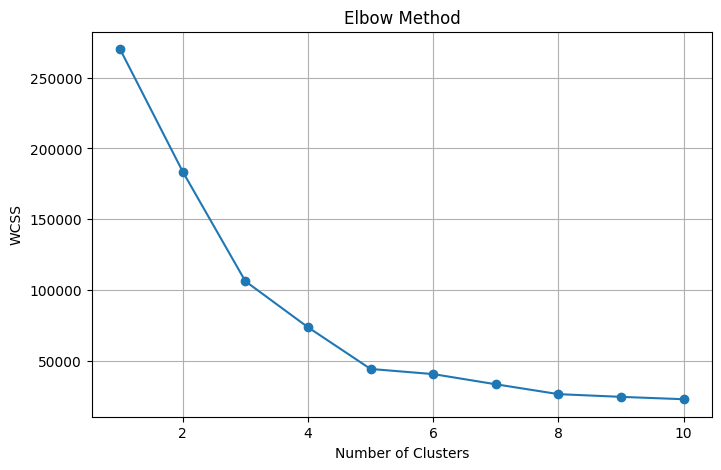

In [ ]:
from sklearn.cluster import KMeans

wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, init='k-means++', random_state=42)
    km.fit(X)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid()
plt.show()

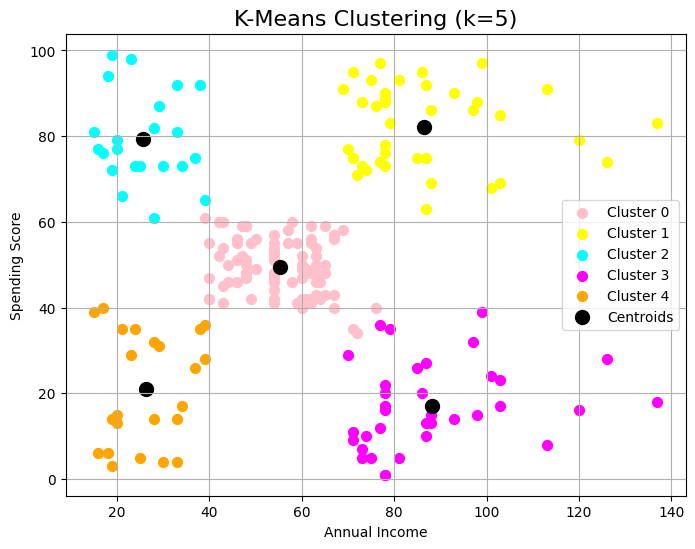

In [ ]:
kmeans5 = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans5 = kmeans5.fit_predict(X)

colors = ['pink', 'yellow', 'cyan', 'magenta', 'orange']

plt.figure(figsize=(8, 6))
for i in range(5):
    plt.scatter(X[y_kmeans5 == i, 0], X[y_kmeans5 == i, 1],
                s=50, c=colors[i], label=f'Cluster {i}')

plt.scatter(kmeans5.cluster_centers_[:, 0], kmeans5.cluster_centers_[:, 1],
            s=100, c='black', label='Centroids')

plt.title('K-Means Clustering (k=5)', fontsize=16)
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.grid()
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

score_kmeans5 = silhouette_score(X, y_kmeans5)
print("Silhouette Score (K-Means, k=5):", score_kmeans5)

Silhouette Score (K-Means, k=5): 0.553931997444648


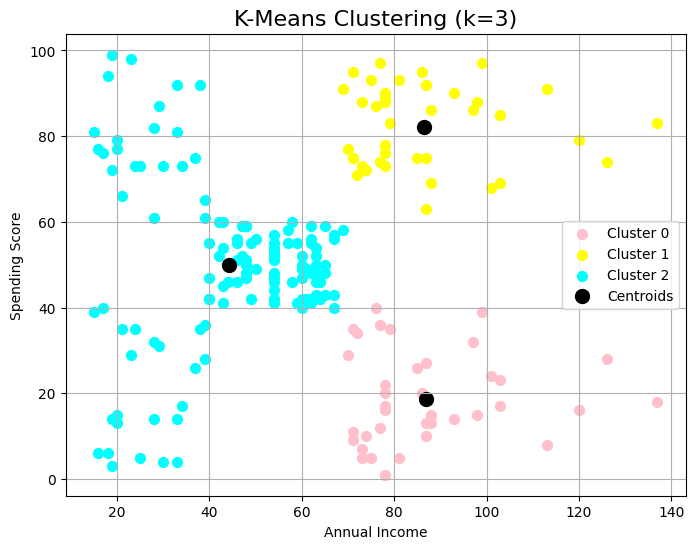

In [ ]:
kmeans3 = KMeans(n_clusters=3, init='k-means++', random_state=42)
y_kmeans3 = kmeans3.fit_predict(X)

plt.figure(figsize=(8, 6))
for i in range(3):
    plt.scatter(X[y_kmeans3 == i, 0], X[y_kmeans3 == i, 1],
                s=50, c=colors[i], label=f'Cluster {i}')

plt.scatter(kmeans3.cluster_centers_[:, 0], kmeans3.cluster_centers_[:, 1],
            s=100, c='black', label='Centroids')

plt.title('K-Means Clustering (k=3)', fontsize=16)
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.grid()
plt.show()

In [ ]:
score_kmeans3 = silhouette_score(X, y_kmeans3)
print("Silhouette Score (K-Means, k=3):", score_kmeans3)

Silhouette Score (K-Means, k=3): 0.46761358158775435


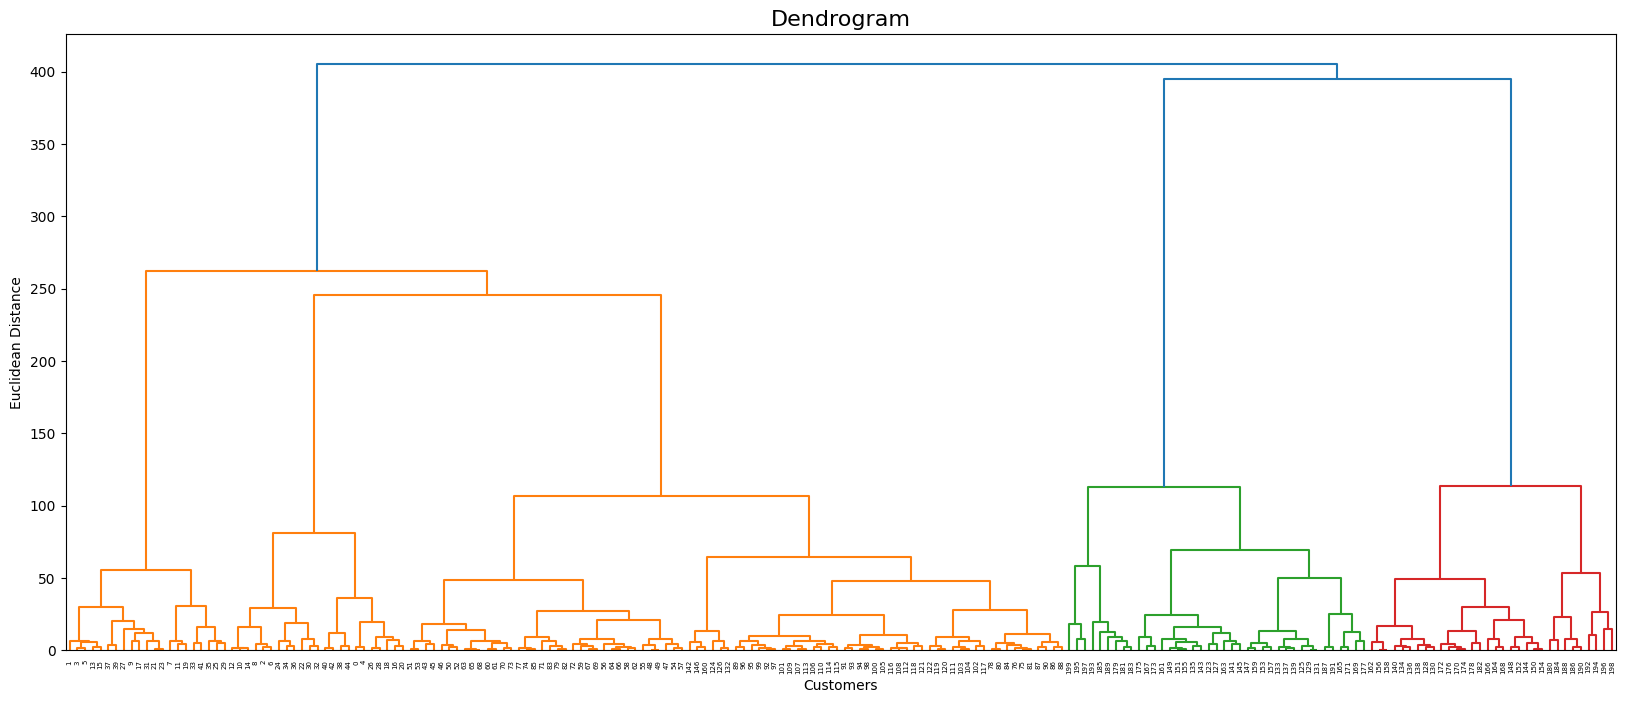

In [ ]:
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(20, 8))
sch.dendrogram(sch.linkage(X, method='ward'))
plt.title('Dendrogram', fontsize=16)
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')
plt.xticks(rotation=90)
plt.show()

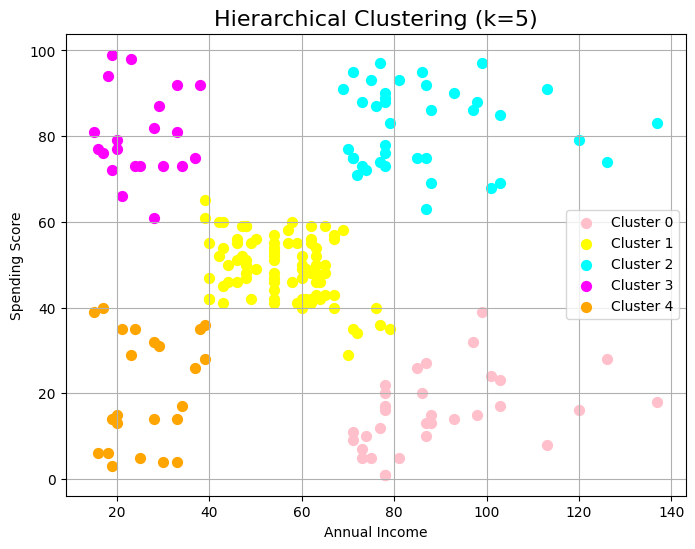

In [ ]:
from sklearn.cluster import AgglomerativeClustering

hc5 = AgglomerativeClustering(n_clusters=5, linkage='ward')
y_hc5 = hc5.fit_predict(X)

plt.figure(figsize=(8, 6))
for i in range(5):
    plt.scatter(X[y_hc5 == i, 0], X[y_hc5 == i, 1],
                s=50, c=colors[i], label=f'Cluster {i}')

plt.title('Hierarchical Clustering (k=5)', fontsize=16)
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.grid()
plt.show()

In [ ]:
score_hc5 = silhouette_score(X, y_hc5)
print("Silhouette Score (Hierarchical, k=5):", score_hc5)

Silhouette Score (Hierarchical, k=5): 0.5529945955148897


In [ ]:
silhouette_scores = []
cluster_range = range(2, 15)

for n in cluster_range:
    hc = AgglomerativeClustering(n_clusters=n, linkage='ward')
    y_hc = hc.fit_predict(X)
    silhouette_scores.append(silhouette_score(X, y_hc))

optimal_n_clusters = list(cluster_range)[np.argmax(silhouette_scores)]
print("Optimal number of clusters:", optimal_n_clusters)

Optimal number of clusters: 5


In [ ]:
hc_best = AgglomerativeClustering(n_clusters=optimal_n_clusters, linkage='ward')
y_hc_best = hc_best.fit_predict(X)

score_hc_best = silhouette_score(X, y_hc_best)
print(f"Silhouette Score (Hierarchical, k={optimal_n_clusters}):", score_hc_best)

Silhouette Score (Hierarchical, k=5): 0.5529945955148897


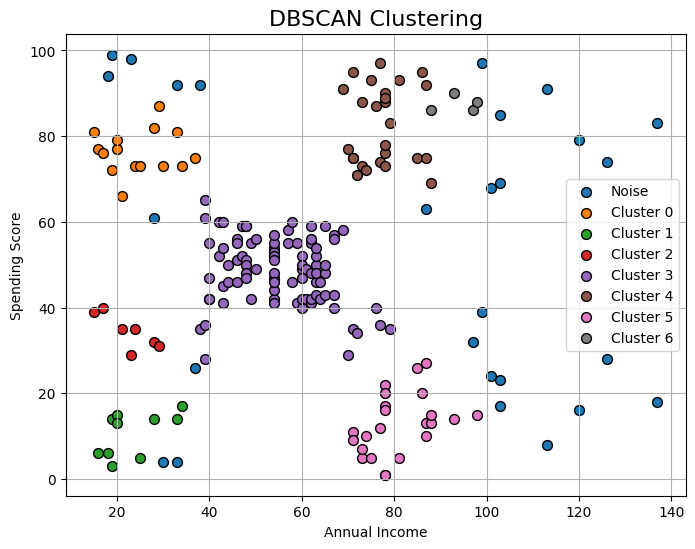

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=9, min_samples=6)
labels_db = dbscan.fit_predict(X)

unique_labels = sorted(set(labels_db))

plt.figure(figsize=(8, 6))
for k in unique_labels:
    label = "Noise" if k == -1 else f"Cluster {k}"
    plt.scatter(X[labels_db == k, 0], X[labels_db == k, 1],
                s=50, edgecolor="k", label=label)

plt.title("DBSCAN Clustering", fontsize=16)
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.grid()
plt.show()

In [ ]:
if len(unique_labels) > 1:
    mask = labels_db != -1
    score_db = silhouette_score(X[mask], labels_db[mask])
    print("Silhouette Score (DBSCAN):", score_db)
else:
    print("DBSCAN found only 1 cluster, silhouette score not defined.")

Silhouette Score (DBSCAN): 0.5018039253022821


In [ ]:
results = pd.DataFrame({
    'Method': ['K-Means (k=5)', 'K-Means (k=3)', f'Hierarchical (k={optimal_n_clusters})', 'DBSCAN'],
    'Silhouette Score': [score_kmeans5, score_kmeans3, score_hc_best, score_db]
}).sort_values('Silhouette Score', ascending=False)

results

,Method,Silhouette Score
0,K-Means (k=5),0.553932
2,Hierarchical (k=5),0.552995
3,DBSCAN,0.501804
1,K-Means (k=3),0.467614
